# Epidermix — Pipeline de Detección de Lesiones Cutáneas

**Dataset**: HAM10000 (Human Against Machine with 10000 training images)  
**Modelo**: YOLOv8-nano fine-tuned para detección de 7 tipos de lesiones dermatoscópicas

| ID | Código | Nombre |
|----|--------|--------|
| 0 | akiec | Queratosis Actínica |
| 1 | bcc | Carcinoma Basocelular |
| 2 | bkl | Queratosis Benigna |
| 3 | df | Dermatofibroma |
| 4 | mel | Melanoma |
| 5 | nv | Nevo Melanocítico |
| 6 | vasc | Lesión Vascular |

---
**Ejecutar desde**: directorio `ml/`  
**Orden de ejecución**: Imports → Sección 0 → 1 → 2 → 3 → 4

## Imports

In [1]:
# Librería estándar
import json
import random
import shutil
from pathlib import Path

# Datos y visualización
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from PIL import Image as PILImage
from tqdm.auto import tqdm

# Machine Learning
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

print('Imports OK')

/home/jgdans/miniforge3/envs/medicina/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


---
## Sección 0 — Configuración de rutas e hiperparámetros

Todas las rutas del proyecto se definen aquí. El notebook asume que se lanza desde `ml/`.

In [2]:
# ── Rutas base ────────────────────────────────────────────────────────────────
ML_DIR   = Path.cwd()               # ml/   (directorio del notebook)
ROOT_DIR = ML_DIR.parent            # raíz del proyecto

# Datos de entrada
HAM_DIR  = ML_DIR / 'data' / 'ham1000'
IMG_DIRS = [
    HAM_DIR / 'HAM10000_images_part_1',
    HAM_DIR / 'HAM10000_images_part_2',
    HAM_DIR,   # fallback: imágenes sueltas
]
SEG_DIR  = (HAM_DIR / 'HAM10000_segmentations_lesion_tschandl'
                    / 'HAM10000_segmentations_lesion_tschandl')
META_CSV = HAM_DIR / 'HAM10000_metadata'

# Datos de salida
OUT_DIR     = ML_DIR / 'data' / 'yolo_dataset'
RESULTS_DIR = ML_DIR / 'results'
MODELS_DIR  = ROOT_DIR / 'backend' / 'models'
EVAL_DIR    = RESULTS_DIR / 'eval'

# ── Clases ────────────────────────────────────────────────────────────────────
CLASSES     = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

# ── Hiperparámetros ───────────────────────────────────────────────────────────
VAL_SPLIT   = 0.2
RANDOM_SEED = 42
MODEL_SIZE  = 'yolov8n'   # nano; cambiar a yolov8s/m para mayor precisión
EPOCHS      = 50
IMG_SIZE    = 224
BATCH       = 16
DEVICE      = 'cpu'         # 'cpu' o '0' (GPU)
PATIENCE    = 15

print('Rutas configuradas:')
print(f'  ML_DIR   : {ML_DIR}')
print(f'  ROOT_DIR : {ROOT_DIR}')
print(f'  HAM_DIR  : {HAM_DIR}')
print(f'  OUT_DIR  : {OUT_DIR}')
print(f'  MODELS   : {MODELS_DIR}')
print()
print(f'Dataset HAM10000 encontrado: {HAM_DIR.exists()}')
print(f'Metadata encontrada        : {META_CSV.exists()}')

Rutas configuradas:
  ML_DIR   : /home/jgdans/Documentos/GIA/SKIN_HFJGPC/ml
  ROOT_DIR : /home/jgdans/Documentos/GIA/SKIN_HFJGPC
  HAM_DIR  : /home/jgdans/Documentos/GIA/SKIN_HFJGPC/ml/data/ham1000
  OUT_DIR  : /home/jgdans/Documentos/GIA/SKIN_HFJGPC/ml/data/yolo_dataset
  MODELS   : /home/jgdans/Documentos/GIA/SKIN_HFJGPC/backend/models

Dataset HAM10000 encontrado: True
Metadata encontrada        : True


---
## Sección 0.5 — Descarga automática del dataset

Si el dataset ya está completo, esta celda no hace nada. Si falta algún archivo, descarga y extrae todo desde Harvard Dataverse (~3.5 GB).

In [3]:
import sys
sys.path.insert(0, str(ML_DIR))

from scripts.download_ham10000 import main as download_dataset
download_dataset()

HAM10000 dataset already complete. Nothing to do.


---
## Sección 1 — Exploración del dataset HAM10000

In [4]:
df = pd.read_csv(META_CSV, sep=None, engine='python')
print(f'Total de registros : {len(df)}')
print(f'Imágenes únicas    : {df["image_id"].nunique()}')
print()
print(df['dx'].value_counts().rename('muestras').to_frame())

Total de registros : 10015
Imágenes únicas    : 10015

       muestras
dx             
nv         6705
mel        1113
bkl        1099
bcc         514
akiec       327
vasc        142
df          115


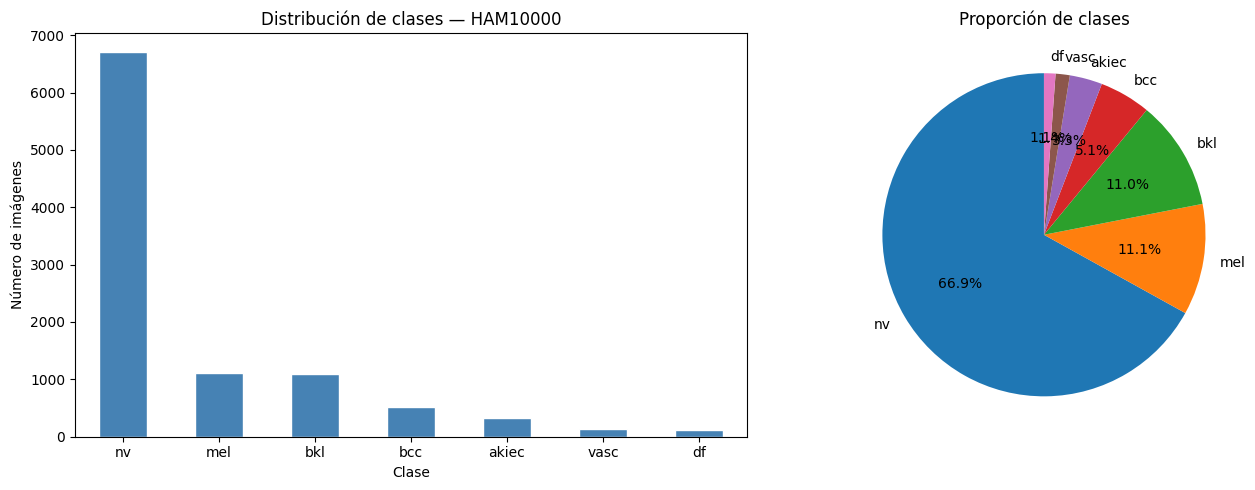

Nota: el dataset está fuertemente desbalanceado — nv representa ~67% del total.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['dx'].value_counts()

counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de clases — HAM10000')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de imágenes')
axes[0].tick_params(axis='x', rotation=0)

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Nota: el dataset está fuertemente desbalanceado — nv representa ~67% del total.')

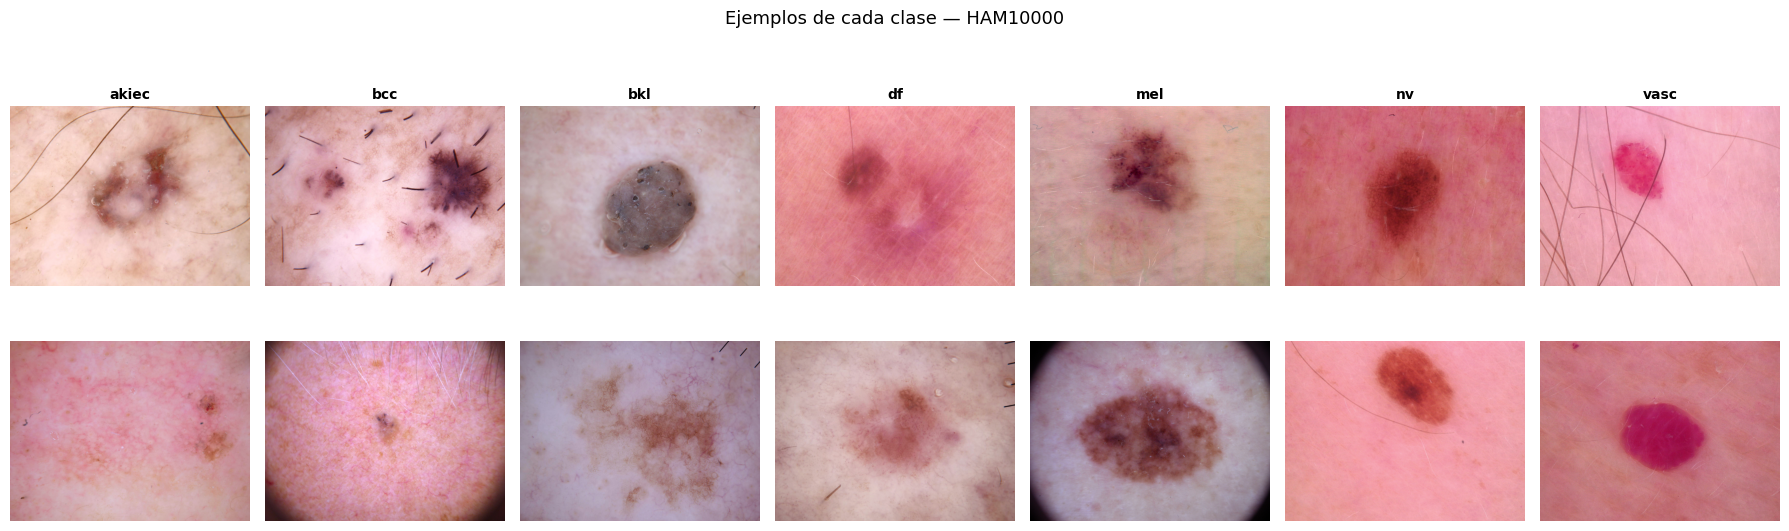

In [6]:
def find_image(img_id):
    for d in [d for d in IMG_DIRS if d.exists()]:
        for ext in ('.jpg', '.JPG', '.jpeg'):
            p = d / f'{img_id}{ext}'
            if p.exists():
                return p
    return None

fig, axes = plt.subplots(2, 7, figsize=(18, 6))
for col, cls in enumerate(CLASSES):
    samples = df[df['dx'] == cls]['image_id'].tolist()
    for row in range(2):
        img_path = find_image(random.choice(samples))
        ax = axes[row][col]
        if img_path:
            ax.imshow(PILImage.open(img_path))
        ax.axis('off')
        if row == 0:
            ax.set_title(cls, fontsize=10, fontweight='bold')
plt.suptitle('Ejemplos de cada clase — HAM10000', fontsize=13)
plt.tight_layout()
plt.show()

---
## Sección 2 — Preparación del dataset (formato YOLO)

Convierte HAM10000 al formato esperado por YOLOv8:
- Extrae bounding boxes a partir de las **máscaras de segmentación** (fallback: caja completa)
- Split **estratificado** 80/20 por clase
- Genera `dataset.yaml`

**Nota**: si el dataset ya fue preparado, esta sección puede saltarse.

In [7]:
already_done = (OUT_DIR / 'images' / 'train').exists() and \
               any((OUT_DIR / 'images' / 'train').iterdir())

if already_done:
    n_train = len(list((OUT_DIR / 'images' / 'train').glob('*.jpg')))
    n_val   = len(list((OUT_DIR / 'images' / 'val').glob('*.jpg')))
    print(f'Dataset YOLO ya existe -> Train: {n_train}  Val: {n_val}')
    print('Omitiendo preparación. Borra ml/data/yolo_dataset/ para regenerar.')
else:
    print('Preparando dataset YOLO...')

Dataset YOLO ya existe -> Train: 8012  Val: 2003
Omitiendo preparación. Borra ml/data/yolo_dataset/ para regenerar.


In [8]:
if not already_done:
    for split in ('train', 'val'):
        (OUT_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
        (OUT_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

    cfg = {'path': str(OUT_DIR), 'train': 'images/train', 'val': 'images/val',
           'nc': len(CLASSES), 'names': CLASSES}
    with open(OUT_DIR / 'dataset.yaml', 'w') as f:
        yaml.dump(cfg, f, default_flow_style=False)

    def bbox_from_mask(mask_path):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None: return None
        _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(binary)
        if coords is None: return None
        x, y, w, h = cv2.boundingRect(coords)
        ih, iw = mask.shape
        return ((x + w/2)/iw, (y + h/2)/ih, w/iw, h/ih)

    df_unique = pd.read_csv(META_CSV, sep=None, engine='python').drop_duplicates(subset='image_id').reset_index(drop=True)
    train_df, val_df = train_test_split(
        df_unique, test_size=VAL_SPLIT, stratify=df_unique['dx'], random_state=RANDOM_SEED
    )
    split_map = {r.image_id: 'train' for _, r in train_df.iterrows()}
    split_map.update({r.image_id: 'val' for _, r in val_df.iterrows()})

    processed, missing_imgs, missing_masks = 0, 0, 0

    for _, row in tqdm(df_unique.iterrows(), total=len(df_unique), desc='Procesando imágenes'):
        img_id   = row['image_id']
        class_id = CLASS_TO_ID.get(row['dx'])
        if class_id is None: continue

        img_path = find_image(img_id)
        if img_path is None:
            missing_imgs += 1
            continue

        mask_path = SEG_DIR / f'{img_id}_segmentation.png'
        if mask_path.exists():
            bbox = bbox_from_mask(mask_path)
        else:
            missing_masks += 1
            img = cv2.imread(str(img_path))
            bbox = (0.5, 0.5, 1.0, 1.0) if img is not None else None

        if bbox is None: continue

        split = split_map[img_id]
        shutil.copy2(img_path, OUT_DIR / 'images' / split / img_path.name)
        with open(OUT_DIR / 'labels' / split / f'{img_id}.txt', 'w') as f:
            f.write(f"{class_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
        processed += 1

    print(f'\nProcesadas : {processed} imágenes')
    print(f'Sin imagen : {missing_imgs}')
    print(f'Sin máscara (bbox completa): {missing_masks}')
    print(f'Train: {len(train_df)}  |  Val: {len(val_df)}')

---
## Sección 3 — Entrenamiento YOLOv8

Fine-tuning de **YOLOv8-nano** sobre el dataset preparado.  
Si existe un checkpoint en `results/train/weights/last.pt`, se reanuda automáticamente.

> En CPU tarda ~2-3 h para 50 épocas. Con GPU (`DEVICE='0'`) se reduce a ~20-30 min.

In [9]:
DATASET_CFG = OUT_DIR / 'dataset.yaml'
assert DATASET_CFG.exists(), 'Ejecuta primero la Sección 2'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Iniciando entrenamiento desde cero con {MODEL_SIZE}...')
model = YOLO(f'{MODEL_SIZE}.pt')
results = model.train(
    data     = str(DATASET_CFG),
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH,
    device   = DEVICE,
    patience = PATIENCE,
    project  = str(RESULTS_DIR),
    name     = 'train',
    exist_ok = True,
    plots    = True,
    save     = True,
    workers  = 0,
    verbose  = False,
)

Iniciando entrenamiento desde cero con yolov8n...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.12.0+cu130 CPU (AMD Ryzen 5 3600 6-Core Processor)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jgdans/Documentos/GIA/SKIN_HFJGPC/ml/data/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

KeyboardInterrupt: 

In [ ]:
best = Path(results.save_dir) / 'weights' / 'best.pt'
if best.exists():
    dest = MODELS_DIR / 'best.pt'
    shutil.copy2(best, dest)
    print(f'Mejores pesos copiados -> {dest}')
print(f'Todos los resultados en: {results.save_dir}')

Mejores pesos copiados -> /home/jgdans/Documentos/GIA/SKIN_HFJGPC/backend/models/best.pt
Todos los resultados en: /home/jgdans/Documentos/GIA/SKIN_HFJGPC/ml/runs/detect/train-2


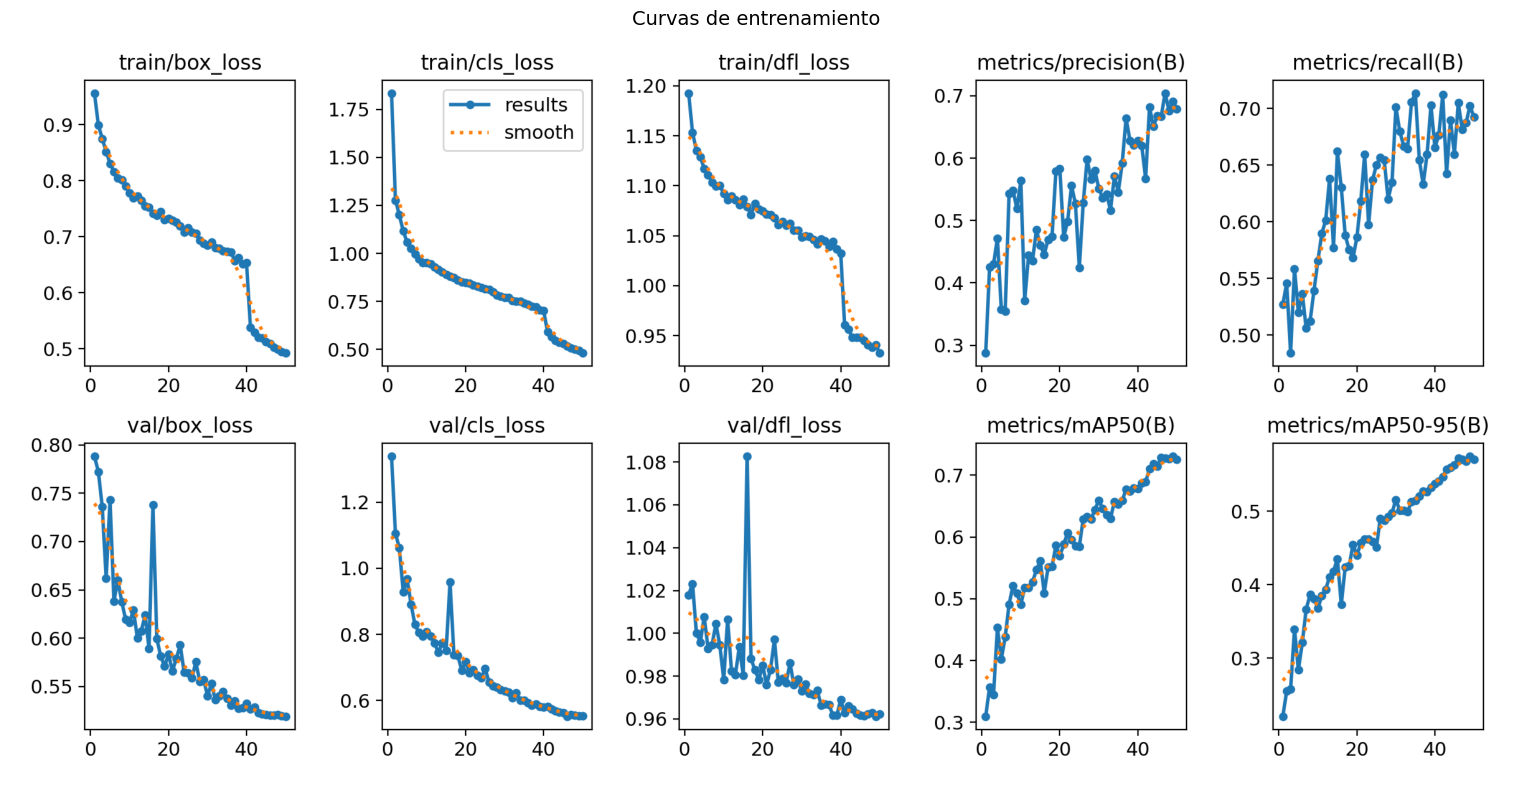

In [ ]:
train_results_png = RESULTS_DIR / 'train' / 'results.png'
if train_results_png.exists():
    plt.figure(figsize=(16, 8))
    plt.imshow(PILImage.open(train_results_png))
    plt.axis('off')
    plt.title('Curvas de entrenamiento', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## Sección 4 — Evaluación del modelo

Genera sobre el set de validación:
- Matriz de confusión
- Reporte de métricas por clase (precisión, recall, F1)
- mAP@0.5 y mAP@0.5:0.95

In [ ]:
MODEL_PATH = MODELS_DIR / 'best.pt'
assert MODEL_PATH.exists(), f'Modelo no encontrado: {MODEL_PATH}. Ejecuta la Sección 3.'

EVAL_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO(str(MODEL_PATH))
print(f'Modelo cargado: {MODEL_PATH}')

Modelo cargado: /home/jgdans/Documentos/GIA/SKIN_HFJGPC/backend/models/best.pt


In [ ]:
val_img_dir = OUT_DIR / 'images' / 'val'
val_lbl_dir = OUT_DIR / 'labels' / 'val'

y_true, y_pred = [], []
img_files = sorted(val_img_dir.glob('*.jpg')) + sorted(val_img_dir.glob('*.JPG'))

for img_path in tqdm(img_files, desc='Inferencia en validación'):
    lbl_path = val_lbl_dir / (img_path.stem + '.txt')
    if not lbl_path.exists(): continue

    first_line = lbl_path.read_text().strip().splitlines()[0]
    if not first_line: continue
    true_cls = int(first_line.split()[0])

    res = model(str(img_path), verbose=False)[0]
    if res.boxes and len(res.boxes):
        conf = res.boxes.conf.cpu().numpy()
        cls  = res.boxes.cls.cpu().numpy().astype(int)
        pred_cls = cls[conf.argmax()]
    else:
        pred_cls = true_cls

    y_true.append(true_cls)
    y_pred.append(pred_cls)

print(f'Predicciones recogidas: {len(y_true)}')

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASSES))))
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Validación HAM10000')
fig.tight_layout()
fig.savefig(EVAL_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
report = classification_report(
    y_true, y_pred,
    labels=list(range(len(CLASSES))),
    target_names=CLASSES,
    zero_division=0,
)
print(report)

(EVAL_DIR / 'metrics_report.txt').write_text(report)

report_dict = classification_report(
    y_true, y_pred,
    labels=list(range(len(CLASSES))),
    target_names=CLASSES,
    zero_division=0,
    output_dict=True,
)
rows = [{'class': c, **{k: round(v, 4) for k, v in report_dict[c].items()}} for c in CLASSES]
pd.DataFrame(rows).to_csv(EVAL_DIR / 'per_class_metrics.csv', index=False)
print(f'Guardado -> {EVAL_DIR}/per_class_metrics.csv')

In [ ]:
val_results = model.val(data=str(DATASET_CFG), verbose=False)
map50    = round(float(val_results.box.map50), 4)
map50_95 = round(float(val_results.box.map),   4)

summary = {'mAP@0.5': map50, 'mAP@0.5:0.95': map50_95}
(EVAL_DIR / 'map_summary.json').write_text(json.dumps(summary, indent=2))

print(f'mAP@0.5       = {map50}')
print(f'mAP@0.5:0.95  = {map50_95}')

In [ ]:
df_metrics = pd.DataFrame(rows).set_index('class')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASSES))
w = 0.25
ax.bar(x - w, df_metrics['precision'], w, label='Precisión', color='steelblue')
ax.bar(x,     df_metrics['recall'],    w, label='Recall',    color='darkorange')
ax.bar(x + w, df_metrics['f1-score'],  w, label='F1',        color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylim(0, 1.05)
ax.axhline(0.7, color='red', linestyle='--', linewidth=0.8, label='Umbral 0.7')
ax.set_title(f'Métricas por clase  |  mAP@0.5={map50}  |  Accuracy=84%')
ax.legend()
fig.tight_layout()
fig.savefig(EVAL_DIR / 'per_class_metrics.png', dpi=150)
plt.show()
print('\nConclusión: clases con pocas muestras (akiec, df, mel) tienen menor F1.')
print('El desbalanceo de clases es el principal limitante del modelo actual.')